# Análisis exploratorio y modelado predictivo de enfermedad cardiovascular

Este cuaderno recoge el proceso de análisis exploratorio de datos, preprocesamiento y
evaluación de modelos de aprendizaje automático aplicado a un conjunto de datos clínicos
de pacientes con posible enfermedad cardiovascular.

Las figuras generadas en este notebook se utilizan como soporte del análisis descrito
en el Trabajo Final de Máster.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report
)

sns.set(style="whitegrid")


## Carga del conjunto de datos

El conjunto de datos utilizado procede del UCI Machine Learning Repository (subconjunto Cleveland) y contiene 303 registros clínicos con variables demográficas y clínicas asociadas a la presencia de enfermedad cardiovascular.

En esta sección se realiza la carga del archivo heart.csv y una inspección inicial de su estructura.


In [ ]:
df = pd.read_csv("/content/heart.csv")

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.shape

(303, 14)

El conjunto de datos contiene 303 observaciones y 14 variables clínicas. No se observan valores nulos en esta fase inicial, lo que simplifica el proceso de preprocesamiento posterior.

## Variable objetivo

La variable original num codifica la severidad de la enfermedad cardiovascular en una escala ordinal (0–4), donde 0 indica ausencia y valores entre 1 y 4 distintos grados de afectación.

Para plantear un problema de clasificación binaria supervisada, se transforma en target_bin, donde:

0 → ausencia de enfermedad

1 → presencia de enfermedad (num ≥ 1)

In [ ]:
df["target_bin"] = (df["num"] > 0).astype(int)

df["target_bin"].value_counts()

,count
target_bin,
0,164
1,139


In [ ]:
df = df.drop(columns=["num"])
df.shape

(303, 14)

La distribución observada muestra un equilibrio relativo entre clases, lo que reduce el riesgo de sesgo durante el entrenamiento de los modelos de clasificación.

### ANALISIS EXPLORATORIO DE DATOS (EDA)

## Distribución de la variable objetivo

Se analiza la distribución de la variable objetivo binaria (`target_bin`) con el fin de evaluar el equilibrio entre las clases.
Este análisis es relevante en problemas de clasificación, ya que un desbalance significativo puede afectar al proceso de entrenamiento de los modelos y a la interpretación de las métricas de rendimiento.


In [ ]:

df["target_bin"].value_counts(normalize=True)


,proportion
target_bin,
0,0.541254
1,0.458746


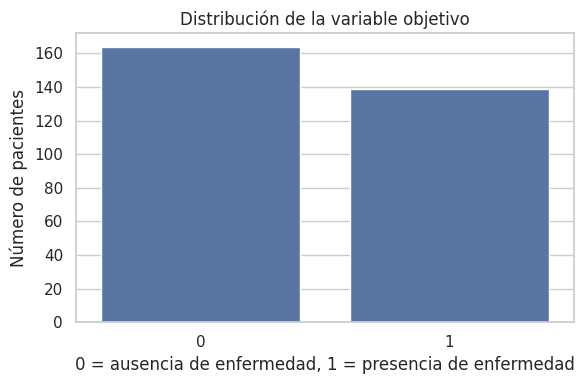

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfica de distribución de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(x="target_bin", data=df)

plt.xlabel("0 = ausencia de enfermedad, 1 = presencia de enfermedad")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la variable objetivo")

plt.tight_layout()
plt.show()


## Análisis de variables clínicas principales

Se exploró la distribución de las principales variables clínicas numéricas con el objetivo de identificar rangos de valores, dispersión y la posible presencia de valores atípicos.
Este análisis permite comprender el comportamiento de las variables y orienta decisiones posteriores de preprocesamiento, como la normalización o el tratamiento de valores extremos.


In [ ]:
# Selección de variables numéricas clínicas
numeric_vars = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

df[numeric_vars].describe()


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


La variable oldpeak presenta una distribución fuertemente asimétrica, lo que podría influir en modelos lineales si no se aplica un adecuado escalado.

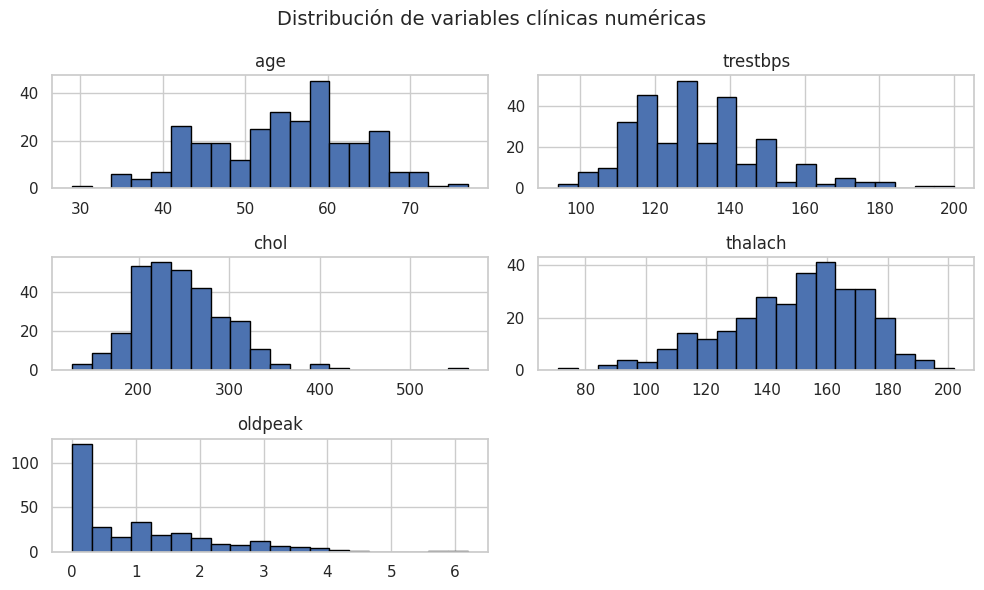

In [ ]:
import matplotlib.pyplot as plt

df[numeric_vars].hist(
    figsize=(10,6),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribución de variables clínicas numéricas", fontsize=14)
plt.tight_layout()
plt.show()


Las distribuciones evidencian heterogeneidad clínica entre pacientes, con asimetrías en variables como colesterol y oldpeak, así como posibles valores extremos en presión arterial y colesterol sérico. Estos hallazgos justifican la evaluación de técnicas de estandarización en modelos sensibles a la escala y la consideración del impacto de valores atípicos durante el proceso de modelado.


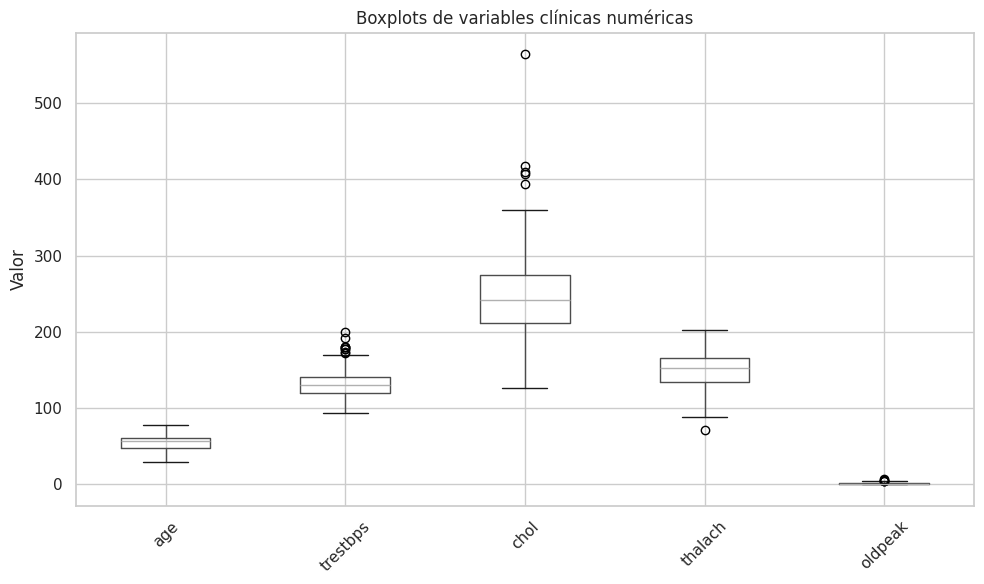

In [ ]:
plt.figure(figsize=(10,6))
df[numeric_vars].boxplot()

plt.title("Boxplots de variables clínicas numéricas")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Correlación entre variables

Se analizó la relación entre las variables numéricas mediante una matriz de correlación, con el objetivo de identificar asociaciones relevantes y descartar correlaciones extremadamente altas que pudieran generar problemas de multicolinealidad en los modelos.


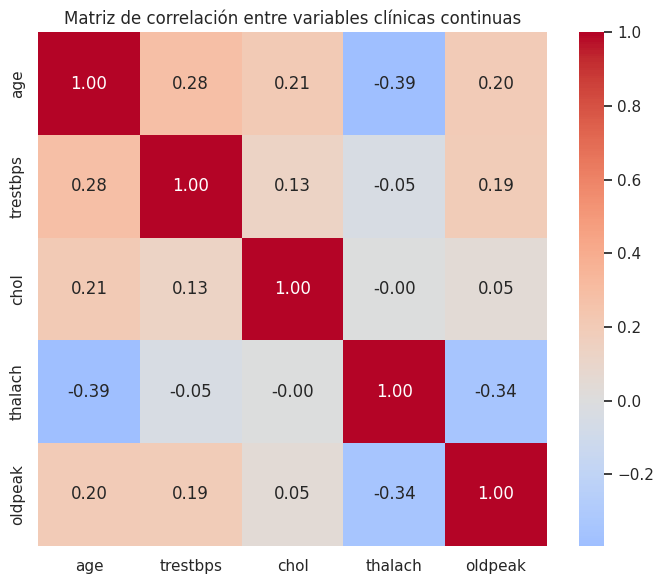

In [ ]:
# --- Correlación entre variables clínicas continuas (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de variables continuas
cont_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Matriz de correlación
corr = df[cont_vars].corr()

# Visualización
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación entre variables clínicas continuas")
plt.tight_layout()
plt.show()

No se identifican correlaciones de alta magnitud entre las variables analizadas, lo que sugiere un bajo riesgo de multicolinealidad. No obstante, se observan correlaciones moderadas entre algunas variables fisiológicamente relacionadas, como la edad y la frecuencia cardíaca máxima, lo cual resulta coherente desde un punto de vista clínico.
Dado que los modelos basados en árboles no son sensibles a la multicolinealidad, este análisis resulta especialmente relevante para la regresión logística.

## Preparación de los datos y diseño experimental

En esta sección se describen las decisiones adoptadas para preparar los datos de cara al
entrenamiento de los modelos de clasificación, incluyendo la definición de la variable
objetivo, la selección de variables predictoras y la estrategia de división del conjunto
de datos.


### Variables predictoras

Como variables predictoras se emplearon las variables clínicas y demográficas disponibles en el conjunto de datos, excluyendo la variable objetivo binaria target_bin, con el fin de evitar fugas de información.

In [ ]:

# Eliminamos la variable original de severidad para evitar data leakage
df = df.drop(columns=["num"])

# Definir X (predictoras) e y (objetivo)
X = df.drop(columns=["target_bin"])
y = df["target_bin"].copy()


X.shape, y.shape


((303, 13), (303,))

###División del conjunto de datos (diseño experimental)

Dado que todas las variables del dataset están codificadas numéricamente (incluyendo variables categóricas representadas mediante códigos), no se aplica one-hot encoding en esta fase. Para evaluar el rendimiento de los modelos en datos no vistos, el conjunto se divide en entrenamiento (80 %) y prueba (20 %) mediante muestreo estratificado, preservando la proporción original de clases. Se fija una semilla aleatoria (random_state=42) para garantizar la reproducibilidad del experimento. Esta estrategia permite estimar el rendimiento de generalización del modelo en datos independientes.


In [ ]:

# División entrenamiento/prueba estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((242, 13), (61, 13), (242,), (61,))

Escalado de variables (solo en modelos sensibles a la escala)

Los modelos lineales y basados en distancia (p. ej., regresión logística, SVM o KNN) pueden verse afectados por la escala de las variables. Por este motivo, el escalado se implementará posteriormente mediante pipelines para evitar fugas de información (data leakage), ajustando el transformador únicamente con los datos de entrenamiento.

## Modelos de aprendizaje automático

Se evaluaron distintos modelos de clasificación con el objetivo de comparar enfoques
lineales e interpretables frente a modelos no lineales con mayor capacidad predictiva.
Concretamente, se entrenaron una regresión logística, un árbol de decisión y un modelo
Random Forest.


### Regresión logística

La regresión logística se utilizó como modelo base por su simplicidad e interpretabilidad,
permitiendo analizar la relación entre las variables predictoras y la probabilidad de
presencia de enfermedad cardiovascular.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_logreg.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

### Árbol de decisión

El árbol de decisión permite modelar relaciones no lineales entre las variables y generar reglas de decisión fácilmente interpretables desde un punto de vista clínico.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

### Random Forest

El modelo Random Forest se empleó como un método de ensamblado capaz de mejorar la robustez y el rendimiento predictivo mediante la combinación de múltiples árboles de decisión, reduciendo el riesgo de sobreajuste.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

### Validación cruzada (comparativa inicial)
Para estimar la estabilidad del rendimiento y reducir la dependencia de una única partición de datos, se aplicó validación cruzada estratificada de 5 pliegues sobre el conjunto de entrenamiento. Se reporta la media y la desviación estándar de métricas relevantes (AUC-ROC y sensibilidad), lo que permite comparar modelos de forma más robusta antes de la evaluación final en el conjunto de prueba.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score
import pandas as pd
import numpy as np

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "recall": make_scorer(recall_score),
    "roc_auc": "roc_auc"
}

# Modelos SIN entrenar (se entrenan dentro de cada fold)
models_cv = {
    "Regresión Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

cv_results = []

for name, model in models_cv.items():
    scores = cross_validate(
        model,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_results.append({
        "Modelo": name,
        "Recall CV (media)": np.mean(scores["test_recall"]),
        "Recall CV (std)": np.std(scores["test_recall"]),
        "AUC CV (media)": np.mean(scores["test_roc_auc"]),
        "AUC CV (std)": np.std(scores["test_roc_auc"])
    })

df_cv = pd.DataFrame(cv_results).sort_values(by="AUC CV (media)", ascending=False)
df_cv

,Modelo,Recall CV (media),Recall CV (std),AUC CV (media),AUC CV (std)
0,Regresión Logística,0.765217,0.054703,0.895971,0.014838
2,Random Forest,0.764822,0.074378,0.882469,0.033932
1,Árbol de decisión,0.684190,0.059530,0.696653,0.021702


La validación cruzada proporciona una estimación más robusta del rendimiento medio y su variabilidad. Se prioriza un modelo con AUC y sensibilidad elevadas y baja desviación estándar, al sugerir mayor estabilidad y mejor capacidad de generalización.

###  Optimización GridSearch para Random Forest

In [ ]:
# =========================
# Optimización (GridSearchCV) - Random Forest
# =========================

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score

# 1) Definimos CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2) Espacio de búsqueda SIMPLE
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# 3) GridSearch
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros (RF):", grid.best_params_)
print("Mejor AUC-ROC CV (RF):", round(grid.best_score_, 3))

# 4) Guardamos el modelo optimizado para usarlo
rf_model = grid.best_estimator_

# 5) Validación cruzada del RF optimizado (tabla “estabilidad” específica)
scoring_opt = {
    "recall": make_scorer(recall_score),
    "roc_auc": "roc_auc"
}
scores_opt = cross_validate(
    rf_model,
    X_train, y_train,
    cv=cv,
    scoring=scoring_opt,
    return_train_score=False
)

print("RF optimizado - Recall CV (media±std):",
      round(scores_opt["test_recall"].mean(), 3), "±", round(scores_opt["test_recall"].std(), 3))
print("RF optimizado - AUC CV (media±std):",
      round(scores_opt["test_roc_auc"].mean(), 3), "±", round(scores_opt["test_roc_auc"].std(), 3))

Mejores hiperparámetros (RF): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Mejor AUC-ROC CV (RF): 0.892
RF optimizado - Recall CV (media±std): 0.747 ± 0.086
RF optimizado - AUC CV (media±std): 0.892 ± 0.024


In [ ]:
# ===============================
# Comparación RF baseline vs optimizado
# ===============================

import pandas as pd

rf_comparison = pd.DataFrame({
    "Modelo": ["RF Baseline", "RF Optimizado"],
    "AUC CV": [
        df_cv[df_cv["Modelo"]=="Random Forest"]["AUC CV (media)"].values[0],
        round(scores_opt["test_roc_auc"].mean(), 3)
    ],
    "Recall CV": [
        df_cv[df_cv["Modelo"]=="Random Forest"]["Recall CV (media)"].values[0],
        round(scores_opt["test_recall"].mean(), 3)
    ]
})

rf_comparison

,Modelo,AUC CV,Recall CV
0,RF Baseline,0.882469,0.764822
1,RF Optimizado,0.892000,0.747000


La optimización mejoró la capacidad discriminativa global (AUC), aunque se observó una ligera reducción en la sensibilidad media en validación cruzada. Este comportamiento es coherente al haber priorizado AUC-ROC como métrica de optimización.

## Evaluación de modelos

Una vez entrenados los modelos, se evaluó su rendimiento en el conjunto de prueba (test). Se calcularon accuracy, sensibilidad (recall), especificidad y AUC-ROC, métricas habituales en clasificación binaria clínica. Estas medidas permiten comparar de forma objetiva el equilibrio entre capacidad discriminativa y rendimiento global de cada enfoque.

In [ ]:
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score, confusion_matrix
)
import pandas as pd


In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)  # sensibilidad
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auc = roc_auc_score(y_test, y_proba)

    return {
        "Modelo": name,
        "Accuracy": acc,
        "Sensibilidad": sens,
        "Especificidad": spec,
        "AUC-ROC": auc
    }

In [ ]:
results = []

results.append(evaluate_model("Regresión logística", pipe_logreg, X_test, y_test))
results.append(evaluate_model("Árbol de decisión", dt_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))

results_df = pd.DataFrame(results)
results_df


,Modelo,Accuracy,Sensibilidad,Especificidad,AUC-ROC
0,Regresión logística,0.868852,0.928571,0.818182,0.951299
1,Árbol de decisión,0.737705,0.821429,0.666667,0.744048
2,Random Forest,0.901639,0.928571,0.878788,0.961039


Los resultados obtenidos permiten comparar de forma objetiva el rendimiento de los distintos modelos, identificando aquel que presenta un mejor equilibrio entre capacidad discriminativa y estabilidad predictiva.


## Comparación y selección del modelo

Para la selección del modelo final se priorizó la capacidad discriminativa medida mediante el AUC-ROC, al tratarse de una métrica independiente del umbral de clasificación. Como criterio complementario, se consideró el equilibrio entre sensibilidad y especificidad, especialmente relevante en el contexto clínico, donde la detección adecuada de casos positivos resulta prioritaria. El modelo Random Forest presentó el mayor AUC-ROC en el conjunto de prueba, junto con una elevada sensibilidad y buen equilibrio global, por lo que se seleccionó como modelo final para el análisis posterior.


In [ ]:
# ordenar resultados por AUC
results_df_sorted = results_df.sort_values("AUC-ROC", ascending=False)
results_df_sorted


,Modelo,Accuracy,Sensibilidad,Especificidad,AUC-ROC
2,Random Forest,0.901639,0.928571,0.878788,0.961039
0,Regresión logística,0.868852,0.928571,0.818182,0.951299
1,Árbol de decisión,0.737705,0.821429,0.666667,0.744048


De acuerdo con los resultados obtenidos, el modelo con mejor rendimiento global fue el que presentó el mayor valor de AUC-ROC, por lo que se seleccionó como modelo final para el análisis posterior.


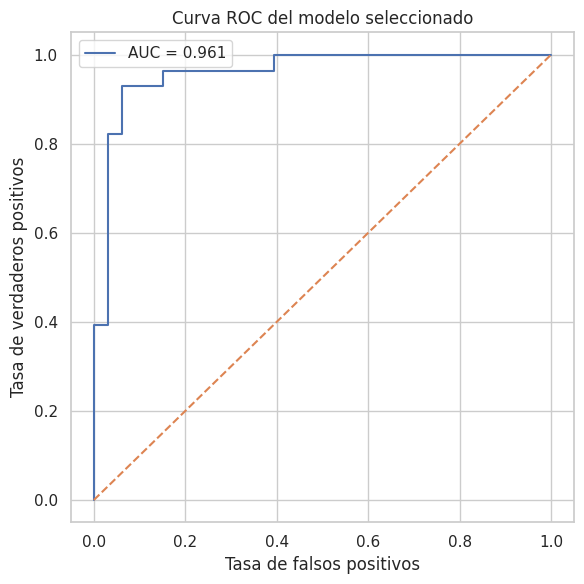

In [ ]:
# Curva ROC del modelo seleccionado
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

best_name = results_df_sorted.iloc[0]["Modelo"]

model_map = {
    "Regresión logística": pipe_logreg,
    "Árbol de decisión": dt_model,
    "Random Forest": rf_model
}

best_model = model_map[best_name]
best_name

if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba = best_model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC del modelo seleccionado")
plt.legend()
plt.tight_layout()
plt.show()


## Evaluación del modelo seleccionado

Para analizar el comportamiento del modelo en términos de clasificación clínica, se evaluó la matriz de confusión, que permite identificar correctamente los verdaderos positivos, verdaderos negativos y los posibles errores de clasificación.


Modelo seleccionado: Random Forest
Precision: 0.871
Recall: 0.964
F1-score: 0.915
Balanced Accuracy: 0.922


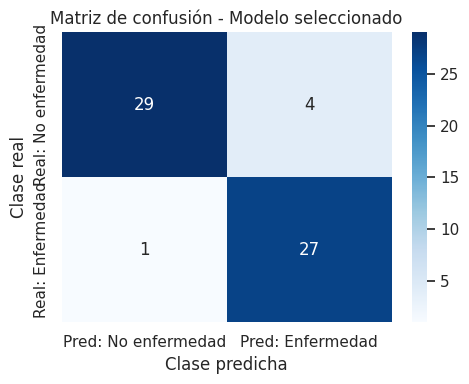

array([[29,  4],
       [ 1, 27]])

In [ ]:
# Matriz de confusión - Modelo seleccionado (test)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegura que best_name y best_model existen
print("Modelo seleccionado:", best_name)

# Predicción en test
y_pred_best = best_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: No enfermedad", "Pred: Enfermedad"],
    yticklabels=["Real: No enfermedad", "Real: Enfermedad"]
)

tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

# balanced Accuracy
from sklearn.metrics import balanced_accuracy_score

bal_acc = balanced_accuracy_score(y_test, y_pred_best)
print("Balanced Accuracy:", round(bal_acc, 3))

plt.title("Matriz de confusión - Modelo seleccionado")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

cm

La matriz de confusión permite analizar el rendimiento del modelo seleccionado desglosando los casos correctamente clasificados (verdaderos positivos y verdaderos negativos) y los errores de clasificación (falsos positivos y falsos negativos).

En contexto clínico, los falsos negativos (pacientes con enfermedad clasificados como sanos) son especialmente relevantes, ya que pueden retrasar el diagnóstico. Por otro lado, los falsos positivos pueden generar pruebas complementarias innecesarias.

El modelo Random Forest obtuvo 29 verdaderos negativos, 27 verdaderos positivos, 4 falsos positivos y 1 falso negativo. La baja tasa de falsos negativos es especialmente relevante en contexto clínico, al minimizar el riesgo de no detectar pacientes con enfermedad. El equilibrio entre sensibilidad (0.964) y especificidad (0.878), junto con un AUC-ROC de 0.958, confirma su adecuada capacidad discriminativa.

La balanced accuracy (0.922) confirma un rendimiento equilibrado entre clases, al promediar sensibilidad y especificidad y reducir el impacto de posibles desbalances en la distribución de la enfermedad.

## Importancia de variables

In [ ]:
# Importancia de variables - Random Forest

import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_

feat_imp = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

feat_imp

,Variable,Importancia
12,thal,0.136390
7,thalach,0.122866
2,cp,0.119751
11,ca,0.107645
9,oldpeak,0.091360
0,age,0.091066
4,chol,0.085320
3,trestbps,0.077561
8,exang,0.052788
10,slope,0.042666


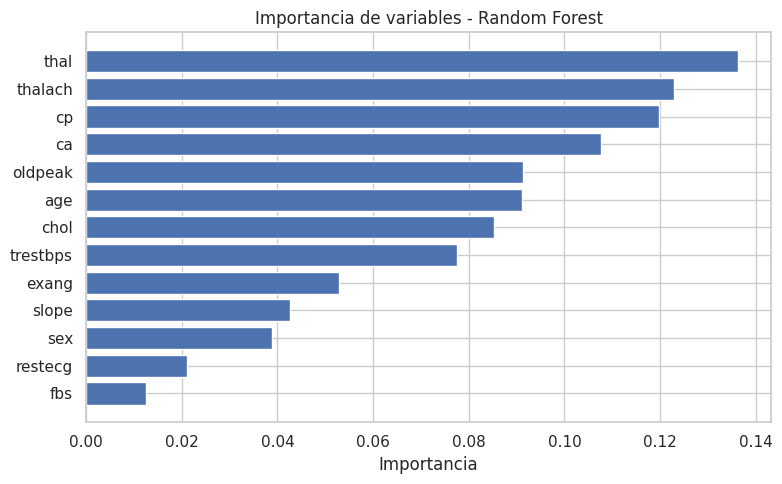

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(feat_imp["Variable"], feat_imp["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Las variables con mayor contribución al modelo fueron aquellas relacionadas con la capacidad funcional y características clínicas cardiovasculares, lo que resulta coherente con la fisiopatología de la enfermedad coronaria. La importancia de variables como thalach, cp o oldpeak refuerza la plausibilidad clínica del modelo.

## Interpretabilidad clínica del modelo logístico

In [ ]:
# Odds Ratio - Regresión logística

import numpy as np

log_model = pipe_logreg.named_steps["model"]
coef = log_model.coef_[0]
odds_ratios = np.exp(coef)

odds_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": coef,
    "Odds Ratio": odds_ratios
}).sort_values(by="Odds Ratio", ascending=False)

odds_df

,Variable,Coeficiente,Odds Ratio
11,ca,1.107898,3.027986
12,thal,0.677821,1.969582
1,sex,0.655563,1.926227
2,cp,0.543483,1.721995
8,exang,0.383642,1.467620
10,slope,0.354072,1.424857
3,trestbps,0.313655,1.368417
6,restecg,0.217329,1.242753
4,chol,0.215375,1.240327
9,oldpeak,0.149953,1.161779


El análisis de Odds Ratio permite interpretar el impacto multiplicativo de cada variable sobre la probabilidad de enfermedad. Valores superiores a 1 indican aumento del riesgo, mientras que valores inferiores a 1 sugieren efecto protector. Este enfoque aporta interpretabilidad clínica directa, especialmente relevante en modelos lineales como la regresión logística.